In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix,roc_curve, auc
from transformers import AutoTokenizer
from transformers import TFAutoModelForSequenceClassification
from sklearn.utils.class_weight import compute_class_weight

In [2]:
print(tf.__version__)

2.18.0


In [3]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")

In [4]:
X_train, y_train = train["clean_text"].values, train["HATEFUL"].values
X_test, y_test = test["clean_text"].values, test["HATEFUL"].values

In [5]:
model_name = "dccuchile/bert-base-spanish-wwm-uncased"
num_classes = 2
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [6]:
max_length= 64
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True,max_length=max_length)
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length = max_length)

In [7]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test
))

In [9]:
model_cw = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels = num_classes)

tf_model.h5:   0%|          | 0.00/537M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['classifier', 'bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

In [11]:
opt = tf.keras.optimizers.AdamW(learning_rate = 2e-5, weight_decay=0.01)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
model_cw.compile(optimizer = opt, loss = loss, metrics = ["accuracy"])

In [ ]:
history_cw = model_cw.fit(train_dataset.batch(16),
          epochs=5,
          validation_data=test_dataset.batch(16),
          class_weight=class_weights)

Epoch 1/5
2103/2103 [==============================] - 606s 262ms/step - loss: 0.5277 - accuracy: 0.7607 - val_loss: 0.4614 - val_accuracy: 0.8140
Epoch 2/5
2103/2103 [==============================] - 545s 259ms/step - loss: 0.3678 - accuracy: 0.8476 - val_loss: 0.3919 - val_accuracy: 0.8411
Epoch 3/5
2103/2103 [==============================] - 542s 258ms/step - loss: 0.2397 - accuracy: 0.8988 - val_loss: 0.4670 - val_accuracy: 0.8417
Epoch 4/5
2103/2103 [==============================] - 542s 258ms/step - loss: 0.1663 - accuracy: 0.9317 - val_loss: 0.5856 - val_accuracy: 0.8133
Epoch 5/5
2103/2103 [==============================] - 572s 272ms/step - loss: 0.1246 - accuracy: 0.9514 - val_loss: 0.5015 - val_accuracy: 0.8497


In [ ]:
y_pred_cw = tf.argmax(model_cw.predict(test_dataset.batch(64)).logits, axis=1)

167/167 [==============================] - 49s 270ms/step


In [ ]:
print(classification_report(y_test, y_pred_cw))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91      8961
           1       0.52      0.67      0.58      1682

    accuracy                           0.85     10643
   macro avg       0.73      0.78      0.75     10643
weighted avg       0.87      0.85      0.86     10643



In [ ]:
logits = model_cw.predict(test_dataset.batch(64)).logits
probabilities = tf.nn.softmax(logits).numpy()
y_scores = probabilities[:, 1]

167/167 [==============================] - 44s 265ms/step


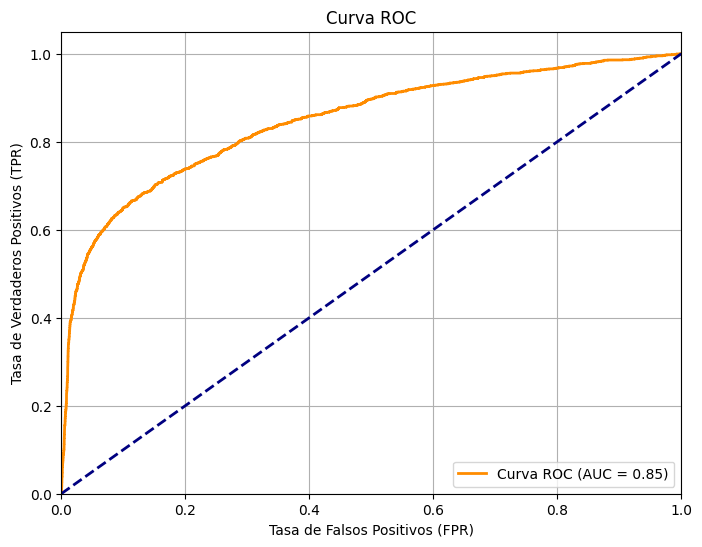

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
!pip install cleanlab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.8/349.8 kB 9.0 MB/s eta 0:00:00


In [ ]:
logits_train = model_cw.predict(train_dataset.batch(64)).logits
probabilities_train = tf.nn.softmax(logits_train).numpy()

526/526 [==============================] - 143s 272ms/step


In [ ]:
import cleanlab

cl_issue_idx = cleanlab.filter.find_label_issues(labels = y_train,
                                                 pred_probs=probabilities_train,
                                                 return_indices_ranked_by='self_confidence',
                                                 )


In [ ]:
y_train_cl = y_train.copy()

In [ ]:
y_train_cl[cl_issue_idx] = np.abs(1 - y_train[cl_issue_idx])

In [ ]:
y_train

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
np.mean(y_train == y_train_cl)

0.9919441141498216

In [ ]:
train_dataset_cl = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train_cl
))

In [ ]:
model_cl = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels = num_classes)
opt_cl = tf.keras.optimizers.AdamW(learning_rate = 2e-5, weight_decay=0.01)
model_cl.compile(optimizer = opt_cl, loss = loss, metrics = ["accuracy"])

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['classifier', 'bert/pooler/dense/bias:0', 'bert/pooler/dense/kernel:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
history_cl = model_cl.fit(train_dataset_cl.batch(16),
          epochs=3,
          validation_data=test_dataset.batch(16),
          class_weight=class_weights)

Epoch 1/3
2103/2103 [==============================] - 626s 265ms/step - loss: 0.5153 - accuracy: 0.7615 - val_loss: 0.4706 - val_accuracy: 0.7957
Epoch 2/3
2103/2103 [==============================] - 542s 258ms/step - loss: 0.3442 - accuracy: 0.8547 - val_loss: 0.4108 - val_accuracy: 0.8352
Epoch 3/3
2103/2103 [==============================] - 544s 259ms/step - loss: 0.2064 - accuracy: 0.9126 - val_loss: 0.5107 - val_accuracy: 0.8326


In [ ]:
y_pred_cl = tf.argmax(model_cl.predict(test_dataset.batch(64)).logits, axis=1)


167/167 [==============================] - 49s 271ms/step


In [ ]:
print(classification_report(y_test, y_pred_cl))

              precision    recall  f1-score   support

           0       0.94      0.86      0.90      8961
           1       0.48      0.69      0.57      1682

    accuracy                           0.83     10643
   macro avg       0.71      0.77      0.73     10643
weighted avg       0.86      0.83      0.84     10643



In [ ]:
logits = model_cl.predict(test_dataset.batch(64)).logits
probabilities = tf.nn.softmax(logits).numpy()
y_scores = probabilities[:, 1]

178/178 [==============================] - 48s 267ms/step


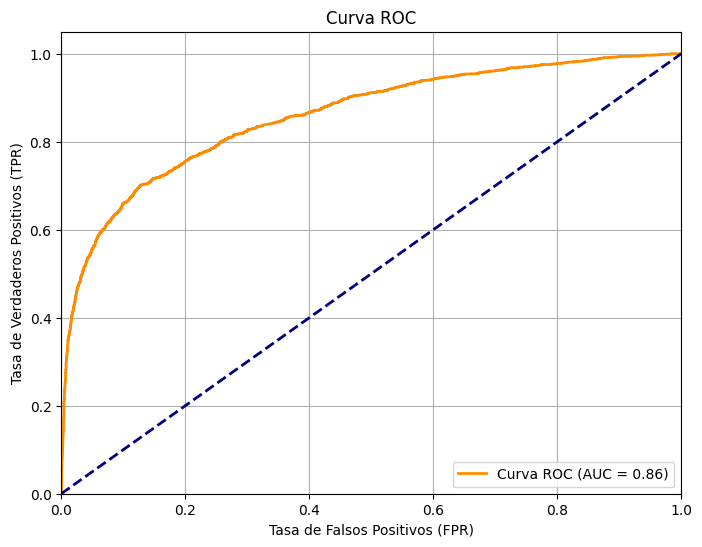

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
np.mean(y_pred_cw.numpy() == y_pred_cl.numpy())

0.9076963766199418

In [ ]:
np.sum(y_pred_cw.numpy() != y_pred_cl.numpy())

1047

In [ ]:
np.sum(y_pred_cw.numpy() != y_pred_cl.numpy()) / len(y_test)

0.09230362338005818

In [ ]:
revision_dict = {"Frase": X_test, "Pred_cl": y_pred_cl.numpy(), "Pred": y_pred_cw.numpy(),
                 "Label": y_test}
revision = pd.DataFrame(revision_dict)

In [ ]:
revision[revision["Pred"] != revision["Pred_cl"]]

,Frase,Pred_cl,Pred,Label
5,jajaja lástima anda bailate tanguito albertite...,1,0,0
16,chuparla,1,0,0
36,toda sacó diego romay juntó años mora godoy ll...,0,1,1
46,jodete ka ka,1,0,1
50,si retraso mental,0,1,0
...,...,...,...,...
11322,buscan igualdad feministas,1,0,1
11326,asi eseste país vamos peronia vamos alberso va...,0,1,0
11333,asesina todavia dio cuenta,0,1,0
11336,mato novio pretenden hacerla xafar mujer conpr...,0,1,0
